# 04 - Model Results

This notebook summarizes training results, compares models, and inspects saved outputs.

In [2]:
from pathlib import Path
import os
import pandas as pd
import json
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\User\Desktop\house-price-prediction")

model_dir = Path("models")



if model_dir.exists():
    for p in sorted(model_dir.glob("*")):
        print("-", p.name)
else:
    print("Models folder not found.")

- best_model.joblib
- best_model_metrics.json
- feature_importance.csv
- model_results.csv
- random_forest_tuning_results.json


## Load model comparison table

In [3]:
comparison_paths = [
    Path("models/model_comparison.csv"),
    Path("models/results.csv"),
    Path("models/metrics_summary.csv"),
]

comparison_path = None
for p in comparison_paths:
    if p.exists():
        comparison_path = p
        break

if comparison_path:
    results_df = pd.read_csv(comparison_path)
    results_df
else:
    print("No model comparison file found.")

No model comparison file found.


## Best model metrics

In [4]:
metrics_paths = [
    Path("models/best_model_metrics.json"),
    Path("models/metrics.json"),
]

metrics_path = None
for p in metrics_paths:
    if p.exists():
        metrics_path = p
        break

if metrics_path:
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)
    metrics
else:
    print("No metrics JSON file found.")

## Feature importance

In [5]:
fi_paths = [
    Path("models/feature_importance.csv"),
    Path("models/top_features.csv"),
]

fi_path = None
for p in fi_paths:
    if p.exists():
        fi_path = p
        break

if fi_path:
    fi = pd.read_csv(fi_path)
    fi.head(20)
else:
    print("No feature importance file found.")

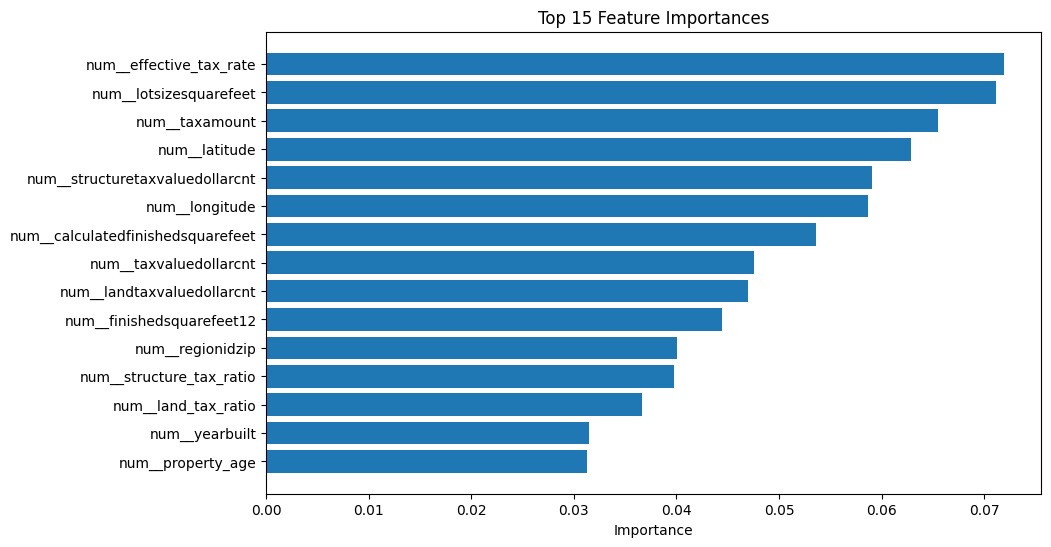

In [6]:
if 'fi' in globals() and isinstance(fi, pd.DataFrame) and {'feature','importance'}.issubset(fi.columns):
    top_fi = fi.head(15).sort_values("importance")
    plt.figure(figsize=(10,6))
    plt.barh(top_fi["feature"], top_fi["importance"])
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.show()

## Interpretation notes

In [7]:
notes = [
    "Check whether tree-based models outperform linear models.",
    "Compare MAE and RMSE to understand sensitivity to large errors.",
    "Review whether engineered tax/value/area features dominate importance.",
    "Document limitations such as missing data, outliers, and leakage risk."
]
pd.DataFrame({"result_interpretation_notes": notes})

,result_interpretation_notes
0,Check whether tree-based models outperform lin...
1,Compare MAE and RMSE to understand sensitivity...
2,Review whether engineered tax/value/area featu...
3,"Document limitations such as missing data, out..."
